In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import ast
import seaborn as sns

df=pd.read_csv(r"C:\Users\SAMA\Downloads\data_jobs.csv")

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

def clean(skills):
    
    if pd.notna(skills):
        
        return ast.literal_eval(skills)
    
    else :
        
        return skills
    
df['job_skills']=df['job_skills'].apply(clean)  

In [2]:
jobs=['Data Analyst','Data Scientist','Data Engineer']
df_data_roles=df[(df['job_title_short'].isin(jobs))&(df['job_country']=='United States')].copy()
df_exploded=df_data_roles.explode('job_skills').copy()

In [3]:
df_grouped=df_exploded.groupby(['job_title_short','job_skills']).size()
df_grouped=df_grouped.reset_index(name='skill_count')

In [5]:
df_grouped.sort_values(by='skill_count',ascending=False,inplace=True)

In [11]:
df_count_jobs=df_data_roles['job_title_short'].value_counts().to_frame()

In [13]:
df_joined=pd.merge(df_count_jobs,df_grouped,how='inner',on='job_title_short')

In [15]:
df_joined['skill_percent']=df_joined['skill_count']/df_joined['count']

In [17]:
df_joined['skill_percent']=df_joined['skill_percent']*100

In [18]:
df_joined

,job_title_short,count,job_skills,skill_count,skill_percent
0,Data Analyst,67816,sql,34452,50.802171
1,Data Analyst,67816,excel,27519,40.578919
2,Data Analyst,67816,tableau,19311,28.475581
3,Data Analyst,67816,python,18382,27.105698
4,Data Analyst,67816,sas,13200,19.464433
...,...,...,...,...,...
662,Data Engineer,35080,qt,1,0.002851
663,Data Engineer,35080,workfront,1,0.002851
664,Data Engineer,35080,sqlserver,1,0.002851
665,Data Engineer,35080,mlpack,1,0.002851


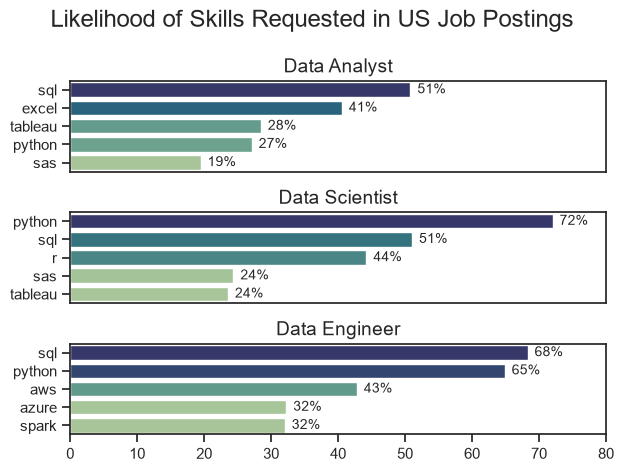

In [59]:
fig,ax=plt.subplots(len(jobs),1)
sns.set_theme(style='ticks')
for i, job_title in enumerate(jobs):

    df_plot = df_joined[df_joined['job_title_short'] == job_title].head().copy()
    
    sns.barplot(df_plot,
                x='skill_percent',
                y='job_skills',
                hue='skill_percent',
                palette='crest',
                ax=ax[i],
                legend=False)

        # Add percentage labels
    for p in ax[i].patches:
        ax[i].annotate(
            f'{p.get_width():.0f}%',
            (p.get_width(), p.get_y() + p.get_height()/2),
            xytext=(5, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=10
        )

    if i!=len(jobs)-1:
        ax[i].set_xticks([])
        
    
    ax[i].set_title(job_title,fontsize=14)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,80)

fig.suptitle(f'Likelihood of Skills Requested in US Job Postings',fontsize=17)    
fig.tight_layout()